In [2]:
# Standard library imports
import json
import os
import shutil
import sys
import re
from collections import Counter, OrderedDict
from glob import glob
# from tqdm import tqdm

# Third-party library imports
import pandas as pd
import concurrent.futures
# from openai import OpenAI

import xarray as xr


from concurrent.futures import ThreadPoolExecutor

%load_ext jupyter_black

In [2]:
from ecmwf.opendata import Client

client = Client()

client.retrieve(
    step=240,
    type="fc",
    param="msl",
    target="data.grib2",
)

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


In [3]:

ds = xr.open_dataset("data.grib2", engine="cfgrib")

print(ds)

<xarray.Dataset> Size: 4MB
Dimensions:     (latitude: 721, longitude: 1440)
Coordinates:
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    meanSea     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Data variables:
    msl         (latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-03T21:35 GRIB to CDM+CF via cfgrib-0.9.1...


In [3]:
ds["msl"].min().values, ds["msl"].max().values

(array(95709.75, dtype=float32), array(104945.75, dtype=float32))

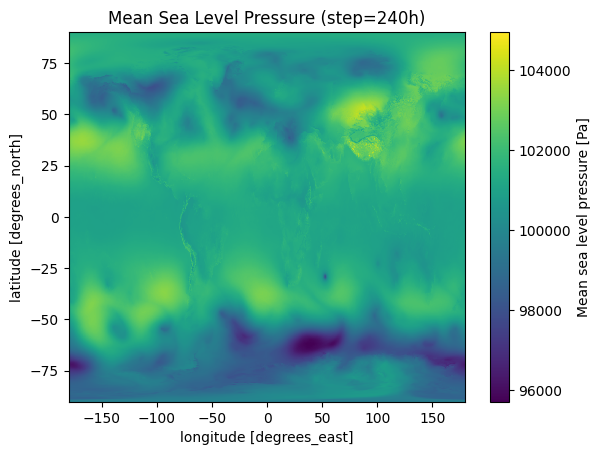

In [4]:
import matplotlib.pyplot as plt

ds["msl"].plot()
plt.title("Mean Sea Level Pressure (step=240h)")
plt.show()

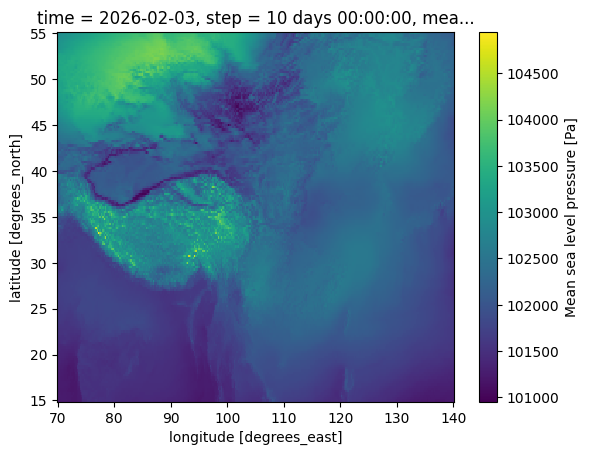

In [5]:
china = ds.sel(latitude=slice(55, 15), longitude=slice(70, 140))

china["msl"].plot()

In [8]:
from datetime import datetime, timedelta, timezone
from ecmwf.opendata import Client

TZ_TAIPEI = timezone(timedelta(hours=8))


def snap_steps(run_dt_utc, target_times_utc):
    """
    把任意目标时间对齐到 ECMWF Open Data 可用的 step：
    - 00/12z: 0-144 每3h；150-360 每6h
    - 06/18z: 0-144 每3h
    返回：去重排序后的合法 step 列表
    """
    run_hour = run_dt_utc.hour
    steps = set()

    for t in target_times_utc:
        lead = (t - run_dt_utc).total_seconds() / 3600.0
        if lead < 0:
            continue

        if run_hour in (0, 12):
            if lead <= 144:
                s = int(round(lead / 3.0) * 3)
                s = max(0, min(144, s))
            else:
                s = int(round(lead / 6.0) * 6)
                s = max(150, min(360, s))
        else:  # 06z / 18z
            s = int(round(lead / 3.0) * 3)
            s = max(0, min(144, s))

        steps.add(s)

    return sorted(steps)


# -------------------------
# 1) latest run
# -------------------------
client = Client(source="ecmwf")
run_dt = client.latest(type="fc", param="msl", step=0)
run_dt_utc = run_dt.replace(tzinfo=timezone.utc)

# -------------------------
# 2) 目标：明天傍晚（本地18/19点）
# -------------------------
now_local = datetime.now(TZ_TAIPEI)
tomorrow = (now_local + timedelta(days=1)).date()

targets_local = [
    datetime(tomorrow.year, tomorrow.month, tomorrow.day, 18, 0, tzinfo=TZ_TAIPEI),
    datetime(tomorrow.year, tomorrow.month, tomorrow.day, 19, 0, tzinfo=TZ_TAIPEI),
]
targets_utc = [t.astimezone(timezone.utc) for t in targets_local]

steps = snap_steps(run_dt_utc, targets_utc)

print("Latest run (UTC):", run_dt_utc)
print("Targets (local):", targets_local)
print("Snapped steps:", steps)

Latest run (UTC): 2026-02-03 06:00:00+00:00
Targets (local): [datetime.datetime(2026, 2, 4, 18, 0, tzinfo=datetime.timezone(datetime.timedelta(seconds=28800))), datetime.datetime(2026, 2, 4, 19, 0, tzinfo=datetime.timezone(datetime.timedelta(seconds=28800)))]
Snapped steps: [27, 30]


In [10]:
# -------------------------
# 3) 下载
# -------------------------
PARAMS = ["tcc", "tp", "2t", "2d", "10u", "10v", "msl"]

client.retrieve(
    type="fc",
    step=steps,
    param=PARAMS,
    target="sanya_sunset_bundle.grib2",
)
print("Saved sanya_sunset_bundle.grib2")

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.
Saved sanya_sunset_bundle.grib2


In [9]:
def _to_frac(x):
    if x is None:
        return None
    return x / 100.0 if x > 1.5 else x  # 兼容 0-1 或 0-100


def _tp_to_mm(tp):
    if tp is None:
        return None
    # ECMWF 常见 tp 单位是 m（水当量），数值通常 < 0.2；转成 mm
    return tp * 1000.0 if tp < 0.5 else tp


def sunset_glow_score_v1(tcc=None, tp=None, t2=None, d2=None):
    """
    只用 Open Data 更稳的字段：tcc, tp, 2t, 2d
    输出：score + label
    """
    tcc = _to_frac(tcc)
    tp_mm = _tp_to_mm(tp)

    score = 0.0

    # 1) 云量窗口：有云但不封天
    if tcc is not None:
        if 0.25 <= tcc <= 0.70:
            score += 2.0
        elif 0.10 <= tcc < 0.25 or 0.70 < tcc <= 0.85:
            score += 1.0
        else:
            score -= 1.0

    # 2) 降水排除：傍晚有明显降水通常减分
    if tp_mm is not None:
        if tp_mm < 0.1:
            score += 1.0
        elif tp_mm < 0.5:
            score += 0.0
        else:
            score -= 2.0

    # 3) 露点差：越大越通透（粗略 proxy）
    if (t2 is not None) and (d2 is not None):
        dd = t2 - d2  # K 或 ℃ 差值都一样
        if dd >= 6:
            score += 1.0
        elif dd >= 3:
            score += 0.5
        else:
            score -= 0.5

    if score >= 3.0:
        label = "晚霞潜力较高"
    elif score >= 1.5:
        label = "可能有普通晚霞/落日云"
    else:
        label = "晚霞潜力较低"

    return score, label

# 读取下载的数据

In [3]:
ds = xr.open_dataset(
    "/share/org/YZWL/yzbsl_luotao/d2l/atmosphere/sanya_sunset_bundle.grib2",
    engine="cfgrib",
)

print(ds)

ERROR:cfgrib.dataset:skipping variable: paramId==167 shortName='t2m'
Traceback (most recent call last):
  File "/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/python3.10/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/python3.10/site-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='heightAboveGround' value=Variable(dimensions=(), data=np.float64(10.0)) new_value=Variable(dimensions=(), data=np.float64(2.0))
ERROR:cfgrib.dataset:skipping variable: paramId==168 shortName='d2m'
Traceback (most recent call last):
  File "/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/python3.10/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/p

<xarray.Dataset> Size: 42MB
Dimensions:            (step: 2, latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] 8B ...
  * step               (step) timedelta64[ns] 16B 1 days 03:00:00 1 days 06:0...
    surface            float64 8B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    valid_time         (step) datetime64[ns] 16B ...
    meanSea            float64 8B ...
    entireAtmosphere   float64 8B ...
    heightAboveGround  float64 8B ...
Data variables:
    tp                 (step, latitude, longitude) float32 8MB ...
    msl                (step, latitude, longitude) float32 8MB ...
    tcc                (step, latitude, longitude) float32 8MB ...
    u10                (step, latitude, longitude) float32 8MB ...
    v10                (step, latitude, longitude) float32 8MB ...
Attributes:
    GRIB_edition:            2
    GRIB_cen

In [4]:
print(ds.dims)
print(list(ds.data_vars))
print(ds.coords)

FrozenMappingWarningOnValuesAccess({'step': 2, 'latitude': 721, 'longitude': 1440})
['tp', 'msl', 'tcc', 'u10', 'v10']
Coordinates:
    time               datetime64[ns] 8B ...
  * step               (step) timedelta64[ns] 16B 1 days 03:00:00 1 days 06:0...
    surface            float64 8B ...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB -180.0 -179.8 ... 179.5 179.8
    valid_time         (step) datetime64[ns] 16B ...
    meanSea            float64 8B ...
    entireAtmosphere   float64 8B ...
    heightAboveGround  float64 8B ...


In [5]:
SANYA_LAT, SANYA_LON = 18.25, 109.50

pt = ds.sel(latitude=SANYA_LAT, longitude=SANYA_LON, method="nearest")
print("nearest lat/lon:", float(pt.latitude.values), float(pt.longitude.values))

nearest lat/lon: 18.25 109.5


In [6]:
def pick_var(ds1, candidates):
    for k in candidates:
        if k in ds1.data_vars:
            return k
    return None


v_tcc = pick_var(ds, ["tcc", "tccs", "cc"])  # 常见就是 tcc
v_tp = pick_var(ds, ["tp", "tp1", "precip"])  # 常见就是 tp
v_t2 = pick_var(ds, ["2t", "t2m", "t2"])  # cfgrib 常是 t2m
v_d2 = pick_var(ds, ["2d", "d2m", "d2"])  # cfgrib 常是 d2m

print("picked:", v_tcc, v_tp, v_t2, v_d2)

picked: tcc tp None None


In [7]:
import pandas as pd
from datetime import timezone, timedelta

TZ = timezone(timedelta(hours=8))


def get_valid_times(ds1):
    if "valid_time" in ds1.coords:
        vt = pd.to_datetime(ds1["valid_time"].values)
    elif ("time" in ds1.coords) and ("step" in ds1.coords):
        t0 = pd.to_datetime(ds1["time"].values)
        st = pd.to_timedelta(ds1["step"].values)
        # 处理 time 可能是标量，step 是向量
        vt = pd.to_datetime(t0) + st
    else:
        raise ValueError("ds does not have valid_time nor (time, step).")
    # 转成带时区（UTC->本地）
    if vt.tz is None:
        vt = vt.tz_localize("UTC")
    return vt.tz_convert("Asia/Taipei")


valid_times_local = get_valid_times(ds)
print(valid_times_local)

DatetimeIndex(['2026-02-04 17:00:00+08:00', '2026-02-04 20:00:00+08:00'], dtype='datetime64[ns, Asia/Taipei]', freq=None)


In [10]:
import numpy as np

# 三亚点
pt = ds.sel(latitude=18.25, longitude=109.5, method="nearest")

# 取需要的变量数组（可能是按 step 维度）
tcc_arr = pt[v_tcc].values if v_tcc else None
tp_arr = pt[v_tp].values if v_tp else None
t2_arr = pt[v_t2].values if v_t2 else None
d2_arr = pt[v_d2].values if v_d2 else None

vt = valid_times_local  # pandas DatetimeIndex

# 明天日期（本地）
tomorrow = (pd.Timestamp.now(tz="Asia/Taipei") + pd.Timedelta(days=1)).date()

# 过滤：明天 17:00-19:30
mask = (vt.date == tomorrow) & (vt.hour >= 17) & (vt.hour <= 19)

rows = []
idxs = np.where(mask)[0]
for i in idxs:
    score, label = sunset_glow_score_v1(
        tcc=tcc_arr[i] if tcc_arr is not None else None,
        tp=tp_arr[i] if tp_arr is not None else None,
        t2=t2_arr[i] if t2_arr is not None else None,
        d2=d2_arr[i] if d2_arr is not None else None,
    )
    rows.append(
        (
            str(vt[i]),
            float(tcc_arr[i]) if tcc_arr is not None else None,
            float(tp_arr[i]) if tp_arr is not None else None,
            score,
            label,
        )
    )

for r in rows:
    print(f"{r[0]} | tcc={r[1]} tp={r[2]} | score={r[3]:.2f} -> {r[4]}")

# 给一个最终结论：取窗口内最高分
if rows:
    best = max(rows, key=lambda x: x[3])
    print("\nFinal (best in window):", best[0], f"score={best[3]:.2f}", best[4])
else:
    print("明天傍晚窗口内没有对应的预报时刻（可能 step 没覆盖到 17-19 点）。")

2026-02-04 17:00:00+08:00 | tcc=0.03125 tp=0.0 | score=0.00 -> 晚霞潜力较低

Final (best in window): 2026-02-04 17:00:00+08:00 score=0.00 晚霞潜力较低


In [11]:
print("dims:", ds.dims)
print("coords:", list(ds.coords))
print("data_vars:", list(ds.data_vars))

dims: FrozenMappingWarningOnValuesAccess({'step': 2, 'latitude': 721, 'longitude': 1440})
coords: ['time', 'step', 'surface', 'latitude', 'longitude', 'valid_time', 'meanSea', 'entireAtmosphere', 'heightAboveGround']
data_vars: ['tp', 'msl', 'tcc', 'u10', 'v10']


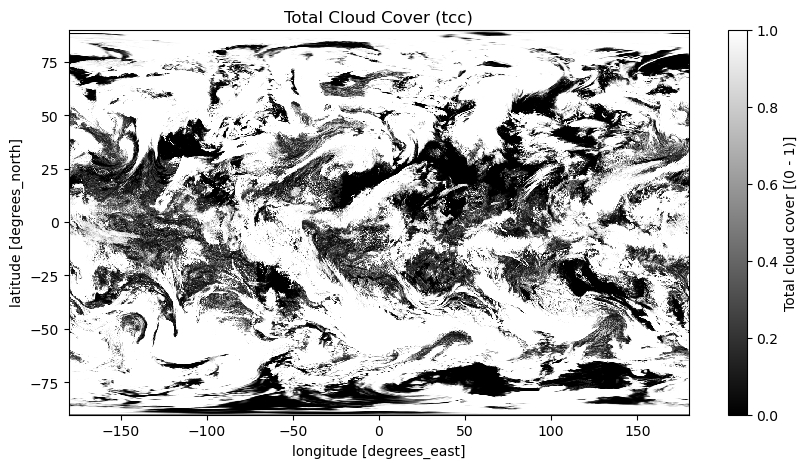

In [12]:
import matplotlib.pyplot as plt

ds["tcc"].isel(step=0).plot(figsize=(10, 5), cmap="gray")
plt.title("Total Cloud Cover (tcc)")
plt.show()

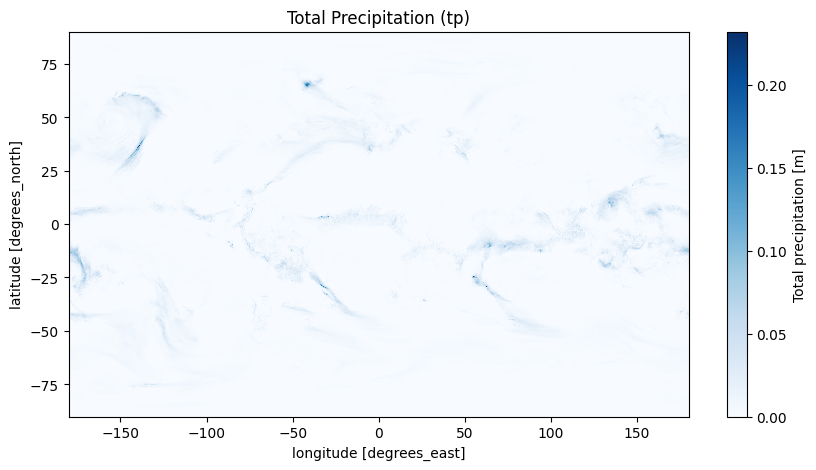

In [22]:
ds["tp"].isel(step=0).plot(figsize=(10, 5), cmap="Blues")
plt.title("Total Precipitation (tp)")
plt.show()

In [23]:
sub = ds.sel(latitude=slice(25, 5), longitude=slice(100, 120))  # 北到南（注意是反的）

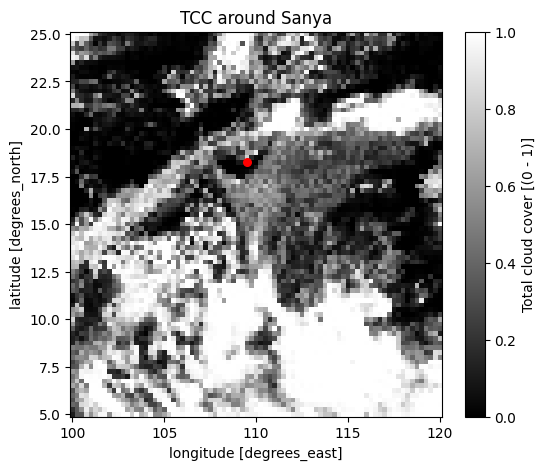

In [24]:
sub["tcc"].isel(step=0).plot(figsize=(6, 5), cmap="gray")
plt.scatter(109.5, 18.25, c="red", s=30)  # 标出三亚
plt.title("TCC around Sanya")
plt.show()

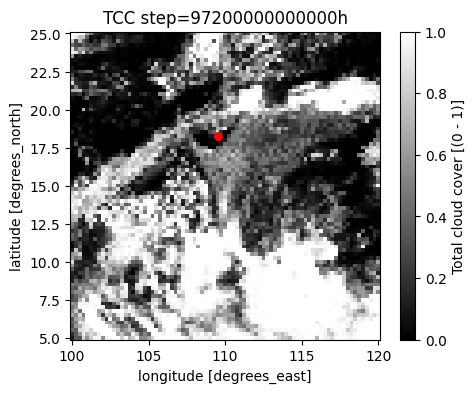

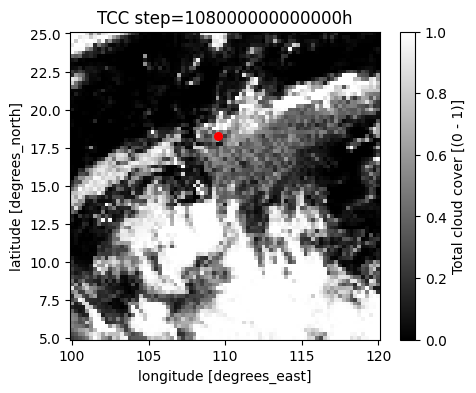

In [26]:
for i, st in enumerate(ds.step.values):
    plt.figure(figsize=(5, 4))
    sub["tcc"].isel(step=i).plot(cmap="gray")
    plt.scatter(109.5, 18.25, c="red", s=30)
    plt.title(f"TCC step={int(st)}h")
    plt.show()

In [10]:
import pandas as pd

vt = (
    pd.to_datetime(ds["valid_time"].values).tz_localize("UTC").tz_convert("Asia/Taipei")
)
print(vt)
print("steps:", ds["step"].values)

DatetimeIndex(['2026-02-04 17:00:00+08:00', '2026-02-04 20:00:00+08:00'], dtype='datetime64[ns, Asia/Taipei]', freq=None)
steps: [ 97200000000000 108000000000000]


/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


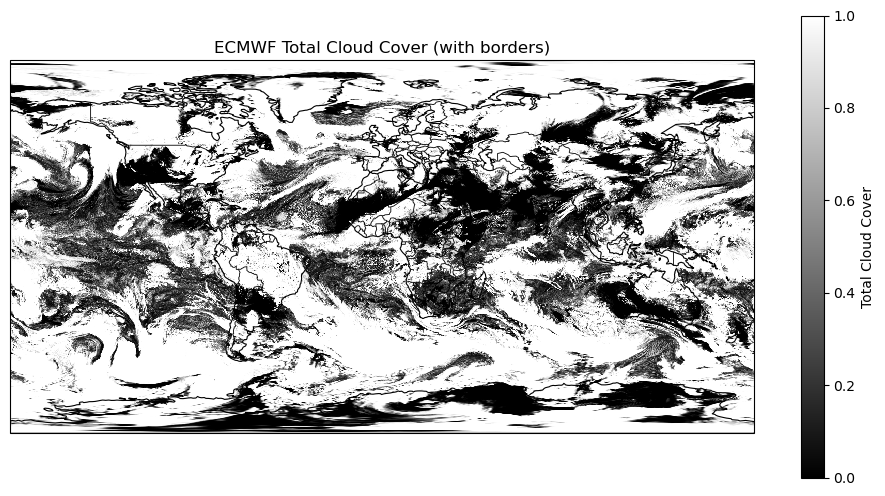

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 选一个时间步
da = ds["tcc"].isel(step=0)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# 画云量
da.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="gray",
    cbar_kwargs={"label": "Total Cloud Cover"},
)

# 加边界
ax.coastlines(resolution="110m", linewidth=0.8)  # 海岸线
ax.add_feature(cfeature.BORDERS, linewidth=0.6)  # 国界

ax.set_title("ECMWF Total Cloud Cover (with borders)")
plt.show()

In [13]:
import sys

print(sys.executable)

/share/apps/anaconda3/envs/JupyterLab4.0.7/bin/python


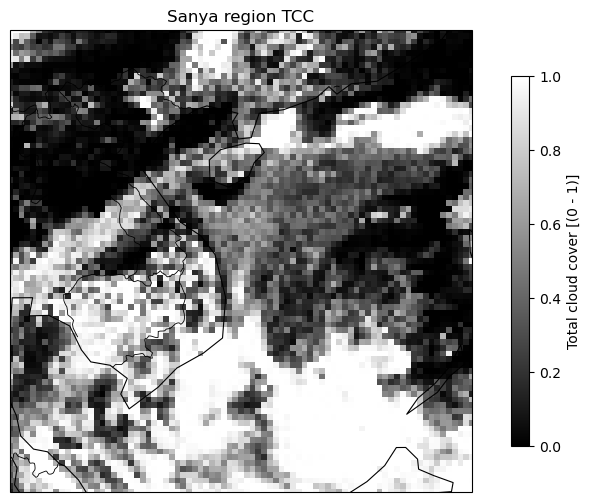

In [18]:
def plot_map(da, title):
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap="gray",
        cbar_kwargs={"shrink": 0.8},
    )

    ax.coastlines("110m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    ax.set_extent([100, 120, 5, 25], crs=ccrs.PlateCarree())

    ax.set_title(title)
    plt.show()


# 用法
plot_map(ds["tcc"].isel(step=0), "Sanya region TCC")

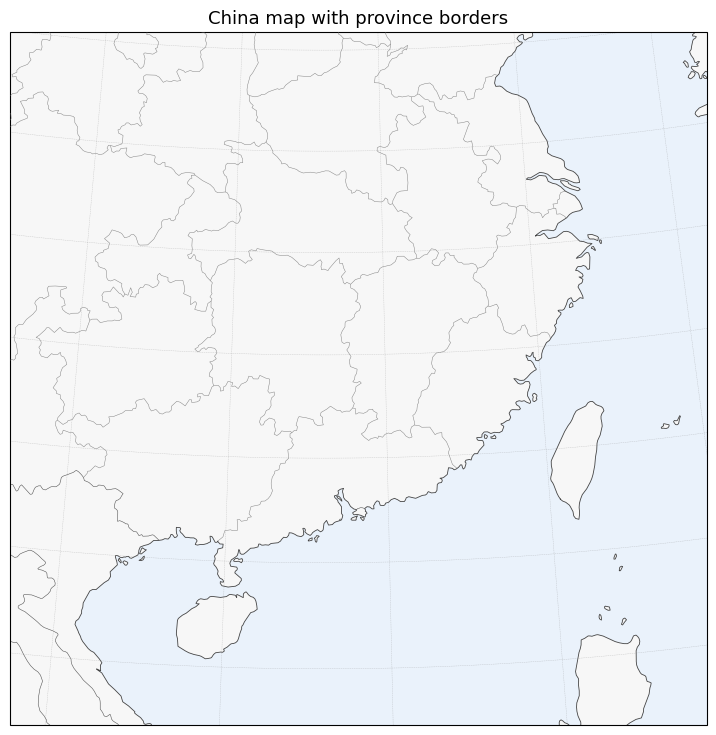

In [33]:
from cartopy.io import shapereader


def add_china_province_borders(ax):
    shp = shapereader.natural_earth(
        resolution="50m",  # 50m 已经够用；10m 会更细但慢
        category="cultural",
        name="admin_1_states_provinces_lines",
    )

    reader = shapereader.Reader(shp)
    geoms = reader.geometries()

    ax.add_geometries(
        geoms,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="#666666",  # 比国界更浅
        linewidth=0.35,
        alpha=0.8,
        zorder=3,
    )


extent = [104, 124, 16, 36]
# lon_min, lon_max, lat_min, lat_max


def plot_china_pretty_base(title="China", extent=extent):
    fig = plt.figure(figsize=(10, 9))
    proj = ccrs.LambertConformal(central_longitude=113, central_latitude=26)
    ax = plt.axes(projection=proj)

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="#f7f7f7", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="#eaf2fb", zorder=0)

    ax.coastlines("50m", linewidth=0.6, color="#444444", zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#555555", zorder=2)

    # ⭐ 省界（新增）
    add_china_province_borders(ax)

    ax.gridlines(
        draw_labels=False,
        linewidth=0.3,
        color="gray",
        alpha=0.4,
        linestyle="--",
        zorder=1,
    )

    ax.set_title(title, fontsize=13)
    plt.show()


plot_china_pretty_base("China map with province borders", extent=extent)

# 晚霞评分”算成整张格点场并画出来

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader

# =========================
# 0) 读数据
# =========================
path = "/share/org/YZWL/yzbsl_luotao/d2l/atmosphere/sanya_sunset_bundle.grib2"
ds = xr.open_dataset(path, engine="cfgrib")

In [43]:
import xarray as xr


def sunset_score_field(ds):
    """
    输入: ds (包含 tcc, tp)
    输出: score (step, lat, lon) 以及一些辅助场
    规则：v0 版（tcc + tp）
    """
    tcc = ds["tcc"]
    tp = ds["tp"]

    # 1) 云量归一化到 0-1（兼容 0-100）
    tcc_frac = xr.where(tcc > 1.5, tcc / 100.0, tcc)

    # 2) tp 转成 mm（多数 ECMWF tp 为 m 水当量）
    tp_mm = xr.where(tp < 0.5, tp * 1000.0, tp)

    # 3) 评分：云量项
    cloud_score = xr.zeros_like(tcc_frac)
    cloud_score = xr.where((tcc_frac >= 0.25) & (tcc_frac <= 0.70), 2.0, cloud_score)
    cloud_score = xr.where(
        ((tcc_frac >= 0.10) & (tcc_frac < 0.25))
        | ((tcc_frac > 0.70) & (tcc_frac <= 0.85)),
        1.0,
        cloud_score,
    )
    cloud_score = xr.where((tcc_frac < 0.10) | (tcc_frac > 0.85), -1.0, cloud_score)

    # 4) 评分：降水项
    rain_score = xr.zeros_like(tp_mm)
    rain_score = xr.where(tp_mm < 0.1, 1.0, rain_score)
    rain_score = xr.where((tp_mm >= 0.1) & (tp_mm < 0.5), 0.0, rain_score)
    rain_score = xr.where(tp_mm >= 0.5, -2.0, rain_score)

    score = cloud_score + rain_score

    return score, tcc_frac, tp_mm


score, tcc_frac, tp_mm = sunset_score_field(ds)
print(score)

<xarray.DataArray (step: 2, latitude: 721, longitude: 1440)> Size: 8MB
array([[[-3., -3., -3., ..., -3., -3., -3.],
        [-3., -3., -3., ..., -3., -3., -3.],
        [-3., -3., -3., ..., -3., -3., -3.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 3.,  3.,  3., ...,  3.,  3.,  3.]],

       [[-3., -3., -3., ..., -3., -3., -3.],
        [-3., -3., -3., ..., -3., -3., -3.],
        [-3., -3., -3., ..., -3., -3., -3.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]]],
      shape=(2, 721, 1440), dtype=float32)
Coordinates:
    time               datetime64[ns] 8B 2026-02-03T06:00:00
  * step               (step) timedelta64[ns] 16B 1 days 03:00:00 1 days 06:0...
    surface            float64 8B 0.0
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 1

In [44]:
# =========================
# 1) 省界
# =========================
def add_china_province_borders(ax):
    shp = shapereader.natural_earth(
        resolution="50m",
        category="cultural",
        name="admin_1_states_provinces_lines",
    )
    ax.add_geometries(
        shapereader.Reader(shp).geometries(),
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="#666666",
        linewidth=0.35,
        alpha=0.8,
        zorder=3,
    )


# =========================
# 2) 晚霞评分：格点场（v0: tcc + tp）
# =========================
def sunset_score_field(ds):
    """
    输入: ds (包含 tcc, tp)
    输出: score (step, lat, lon) 以及 tcc_frac, tp_mm
    """
    tcc = ds["tcc"]
    tp = ds["tp"]

    # 云量归一化到 0-1（兼容 0-100）
    tcc_frac = xr.where(tcc > 1.5, tcc / 100.0, tcc)

    # tp 转成 mm（多数 ECMWF tp 为 m 水当量）
    tp_mm = xr.where(tp < 0.5, tp * 1000.0, tp)

    # 云量评分
    cloud_score = xr.zeros_like(tcc_frac)
    cloud_score = xr.where((tcc_frac >= 0.25) & (tcc_frac <= 0.70), 2.0, cloud_score)
    cloud_score = xr.where(
        ((tcc_frac >= 0.10) & (tcc_frac < 0.25))
        | ((tcc_frac > 0.70) & (tcc_frac <= 0.85)),
        1.0,
        cloud_score,
    )
    cloud_score = xr.where((tcc_frac < 0.10) | (tcc_frac > 0.85), -1.0, cloud_score)

    # 降水评分
    rain_score = xr.zeros_like(tp_mm)
    rain_score = xr.where(tp_mm < 0.1, 1.0, rain_score)
    rain_score = xr.where((tp_mm >= 0.1) & (tp_mm < 0.5), 0.0, rain_score)
    rain_score = xr.where(tp_mm >= 0.5, -2.0, rain_score)

    score = cloud_score + rain_score

    # score<0 截断为 0
    score = score.clip(min=0)

    return score, tcc_frac, tp_mm


# =========================
# 3) 自定义 colormap：0透明 -> 3红色不透明，中间平滑过渡
# =========================
def sunset_score_cmap():
    """
    score: 0..3
    0  : 透明（alpha=0）
    3  : 红色不透明（alpha=1）
    颜色：黄->橙->红（通过 G 通道递减）
    """
    N = 256
    xs = np.linspace(0, 1, N)

    rgba = np.zeros((N, 4))
    # RGB: (1, G, 0) 让颜色从黄(1,1,0) -> 红(1,0,0)
    rgba[:, 0] = 1.0
    rgba[:, 1] = np.clip(1.15 - 1.15 * xs, 0, 1)
    rgba[:, 2] = 0.0
    # Alpha: 0 -> 1
    rgba[:, 3] = xs

    return mcolors.ListedColormap(rgba, name="sunset_score")


# =========================
# 4) 画图：东南部放大 + 省界 + score overlay（0透明）
# =========================
def plot_score_map(
    score_da,
    ds,
    step_idx=0,
    extent=(104, 124, 16, 36),
    title_prefix="Sunset glow score (0 transparent, 3 red)",
    sanya_lat=18.25,
    sanya_lon=109.50,
):
    # 本地时间标签
    vt = (
        pd.to_datetime(ds["valid_time"].values)
        .tz_localize("UTC")
        .tz_convert("Asia/Taipei")
    )
    t_label = str(vt[step_idx])

    fig = plt.figure(figsize=(9, 7))
    proj = ccrs.LambertConformal(central_longitude=113, central_latitude=26)
    ax = plt.axes(projection=proj)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # 底图
    ax.add_feature(cfeature.LAND, facecolor="#f7f7f7", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="#eaf2fb", zorder=0)

    # 0 完全透明：直接 mask 掉
    score_plot = score_da.where(score_da > 0)

    # 叠加评分场
    cmap = sunset_score_cmap()
    score_plot.isel(step=step_idx).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        x="longitude",
        y="latitude",
        cmap=cmap,
        vmin=0,
        vmax=3,
        add_colorbar=True,
        cbar_kwargs={"shrink": 0.8, "label": "score", "ticks": [0, 1, 2, 3]},
        zorder=1,
    )

    # 边界与网格
    ax.coastlines("50m", linewidth=0.6, color="#444444", zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#555555", zorder=2)
    add_china_province_borders(ax)

    ax.gridlines(
        draw_labels=False,
        linewidth=0.3,
        color="gray",
        alpha=0.35,
        linestyle="--",
        zorder=0,
    )

    # 标出三亚
    ax.scatter(sanya_lon, sanya_lat, s=50, transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title(
        f"{title_prefix} | {t_label} | step={int(ds.step.values[step_idx])}h",
        fontsize=12,
    )
    plt.show()

In [ ]:
# =========================
# 5) 跑起来：算分 + 画两帧
# =========================
score, tcc_frac, tp_mm = sunset_score_field(ds)

# 看看两帧对应的本地时间，确保你画的是你想要的时段
vt_local = (
    pd.to_datetime(ds["valid_time"].values).tz_localize("UTC").tz_convert("Asia/Taipei")
)
print("valid_time (local):", list(vt_local))
print("steps:", ds.step.values)

plot_score_map(score, ds, step_idx=0)
plot_score_map(score, ds, step_idx=1)

In [ ]:
from ecmwf.opendata import Client

PARAMS = ["tcc", "lcc", "mcc", "hcc", "2t", "2d", "10u", "10v", "msl", "tp"]
STEPS = list(range(18, 20, 1))  # AIFS Single：6小时步长


def try_download_aifs_single(target="aifs_single_bundle.grib2"):
    # 按可靠性“轮询”不同源：平台偶尔会缺某个时次，换源通常就好了
    for source in ["ecmwf", "aws", "google", "azure"]:
        try:
            client = Client(source=source, model="aifs-single", resol="0p25")

            # 关键：用合法 step=0 + 常见 param=tcc 去找最近可用 run
            run_dt = client.latest(type="fc", step=0, param="tcc")  # 返回 datetime
            date_str = run_dt.strftime("%Y-%m-%d %H:%M:%S")
            print(f"[{source}] latest run = {date_str}")

            client.retrieve(
                type="fc",
                stream="oper",
                date=date_str,
                step=STEPS,
                param=PARAMS,
                target=target,
            )
            print(f"✅ downloaded from {source} -> {target}")
            return date_str, source

        except Exception as e:
            print(f"❌ source={source} failed: {type(e).__name__}: {e}")

    raise RuntimeError(
        "All sources failed. Likely temporary availability / network / rolling window issue."
    )


date_str, source = try_download_aifs_single("aifs_single_cloud_layers_0p25.grib2")
print("final:", date_str, source)

[ecmwf] latest run = 2026-02-03 06:00:00
❌ source=ecmwf failed: HTTPError: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20260203/06z/aifs-single/0p25/oper/20260203060000-19h-oper-fc.index
[aws] latest run = 2026-02-03 06:00:00
❌ source=aws failed: HTTPError: 404 Client Error: Not Found for url: https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260203/06z/aifs-single/0p25/oper/20260203060000-19h-oper-fc.index


[18]

In [55]:
import xarray as xr

ds = xr.open_dataset("aifs_single_cloud_layers_0p25.grib2", engine="cfgrib")

print("data_vars:", list(ds.data_vars))
print("dims:", ds.dims)
print("steps:", ds.step.values, "...", ds.step.values)

ERROR:cfgrib.dataset:skipping variable: paramId==167 shortName='t2m'
Traceback (most recent call last):
  File "/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/python3.10/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/python3.10/site-packages/cfgrib/dataset.py", line 642, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='heightAboveGround' value=Variable(dimensions=(), data=np.float64(10.0)) new_value=Variable(dimensions=(), data=np.float64(2.0))
ERROR:cfgrib.dataset:skipping variable: paramId==168 shortName='d2m'
Traceback (most recent call last):
  File "/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/python3.10/site-packages/cfgrib/dataset.py", line 726, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "/share/org/YZWL/yzbsl_luotao/.conda/envs/weather/lib/p

data_vars: ['mcc', 'hcc', 'msl', 'u10', 'v10', 'tcc', 'tp', 'lcc']
dims: FrozenMappingWarningOnValuesAccess({'latitude': 721, 'longitude': 1440})
steps: 64800000000000 nanoseconds ... 64800000000000 nanoseconds


In [67]:
import numpy as np
import xarray as xr


def _to_frac(da):
    return xr.where(da > 1.5, da / 100.0, da)


def _tp_to_mm(tp):
    return xr.where(tp < 0.5, tp * 1000.0, tp)


def sunset_score_field_v1(ds):
    tcc = _to_frac(ds["tcc"])
    lcc = _to_frac(ds["lcc"])
    mcc = _to_frac(ds["mcc"])
    hcc = _to_frac(ds["hcc"])
    tp_mm = _tp_to_mm(ds["tp"])

    wind10 = xr.apply_ufunc(np.hypot, ds["u10"], ds["v10"], dask="allowed")
    msl = ds["msl"]

    # A) 总云量项（沿用你的 v0）
    cloud_score = xr.zeros_like(tcc)
    cloud_score = xr.where((tcc >= 0.25) & (tcc <= 0.70), 2.0, cloud_score)
    cloud_score = xr.where(
        ((tcc >= 0.10) & (tcc < 0.25)) | ((tcc > 0.70) & (tcc <= 0.85)),
        1.0,
        cloud_score,
    )
    cloud_score = xr.where((tcc < 0.10) | (tcc > 0.85), -1.0, cloud_score)

    # B) 降水项
    rain_score = xr.zeros_like(tp_mm)
    rain_score = xr.where(tp_mm < 0.1, 1.0, rain_score)
    rain_score = xr.where((tp_mm >= 0.1) & (tp_mm < 0.5), -2, rain_score)
    rain_score = xr.where(tp_mm >= 0.5, -5.0, rain_score)

    # C) 云层结构项
    structure_score = xr.zeros_like(tcc)

    # 低云惩罚
    structure_score = xr.where(lcc > 0.60, structure_score - 2.0, structure_score)
    structure_score = xr.where(
        (lcc > 0.35) & (lcc <= 0.60), structure_score - 1.0, structure_score
    )

    # 中云适中加分/过厚扣分
    structure_score = xr.where(
        (mcc >= 0.15) & (mcc <= 0.55), structure_score + 1.0, structure_score
    )
    structure_score = xr.where(mcc > 0.80, structure_score - 1.0, structure_score)

    # 高云适中加分/过厚扣分
    structure_score = xr.where(
        (hcc >= 0.10) & (hcc <= 0.50), structure_score + 1.0, structure_score
    )
    structure_score = xr.where(hcc > 0.75, structure_score - 1.0, structure_score)

    # 纯晴（中高云都很少且总云量很低）轻微扣分
    structure_score = xr.where(
        (mcc < 0.10) & (hcc < 0.10) & (tcc < 0.15),
        structure_score - 0.5,
        structure_score,
    )

    # D) 风速项（弱惩罚）
    wind_score = xr.zeros_like(tcc)
    wind_score = xr.where(wind10 >= 12.0, -1.0, wind_score)
    wind_score = xr.where((wind10 >= 7.0) & (wind10 < 12.0), -0.5, wind_score)

    # E) 气压项（相对高压弱加分）
    latlon_dims = [d for d in msl.dims if d in ("latitude", "longitude")]
    msl_med = msl.median(dim=latlon_dims, skipna=True)
    pressure_score = xr.where(msl >= msl_med, 0.3, 0.0)

    score = cloud_score + rain_score + structure_score + wind_score + pressure_score

    # 你原来有 score<0 截断为0，这里保留
    score = score.clip(min=0)

    aux = xr.Dataset(
        dict(
            tcc_frac=tcc,
            lcc_frac=lcc,
            mcc_frac=mcc,
            hcc_frac=hcc,
            tp_mm=tp_mm,
            wind10=wind10,
            cloud_score=cloud_score,
            rain_score=rain_score,
            structure_score=structure_score,
            wind_score=wind_score,
            pressure_score=pressure_score,
        )
    )
    return score, aux


def ensure_step_dim(da, ds):
    """
    如果 ds/da 没有 step 维，则扩一维 step=[0]，便于 isel(step=...)
    """
    if "step" not in da.dims:
        da = da.expand_dims(step=[0])
    return da


def step_hours(ds, step_idx=0):
    """
    把 ds.step（timedelta64 或数值）转成小时整数，用于标题显示。
    若 ds 没有 step，返回 0。
    """
    if "step" not in ds.coords and "step" not in ds.variables:
        return 0
    v = ds["step"].values
    # v 可能是标量，也可能是数组
    if np.ndim(v) == 0:
        td = np.timedelta64(v) if isinstance(v, (np.timedelta64,)) else v
    else:
        td = v[step_idx]
    try:
        # timedelta64 -> 小时
        return int(td / np.timedelta64(1, "h"))
    except Exception:
        # 兜底：如果已经是小时或其他数值
        return int(td)


def plot_score_map(
    score_da,
    ds,
    step_idx=0,
    extent=(104, 124, 16, 36),
    title_prefix="Sunset glow score (0 transparent, 3 red)",
    sanya_lat=18.25,
    sanya_lon=109.50,
):
    # --- 让 score 一定有 step 维 ---
    score_da = ensure_step_dim(score_da, ds)

    # --- valid_time 兼容：标量 or 数组 ---
    if "valid_time" in ds:
        vt_raw = ds["valid_time"].values
        vt = pd.to_datetime(vt_raw)
        if np.ndim(vt_raw) == 0:
            vt_one = vt
        else:
            vt_one = vt[step_idx]
        vt_one = vt_one.tz_localize("UTC").tz_convert("Asia/Taipei")
        t_label = str(vt_one)
    else:
        t_label = "valid_time: N/A"

    # --- step 小时 ---
    sh = step_hours(ds, step_idx=step_idx)

    fig = plt.figure(figsize=(9, 7))
    proj = ccrs.LambertConformal(central_longitude=113, central_latitude=26)
    ax = plt.axes(projection=proj)
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # 底图
    ax.add_feature(cfeature.LAND, facecolor="#f7f7f7", zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor="#eaf2fb", zorder=0)

    # 0 完全透明：mask
    score_plot = score_da.where(score_da > 0)

    cmap = sunset_score_cmap()
    score_plot.isel(step=step_idx).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        x="longitude",
        y="latitude",
        cmap=cmap,
        vmin=0,
        vmax=3,
        add_colorbar=True,
        cbar_kwargs={"shrink": 0.8, "label": "score", "ticks": [0, 1, 2, 3]},
        zorder=1,
    )

    ax.coastlines("50m", linewidth=0.6, color="#444444", zorder=2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="#555555", zorder=2)
    add_china_province_borders(ax)

    ax.gridlines(
        draw_labels=False,
        linewidth=0.3,
        color="gray",
        alpha=0.35,
        linestyle="--",
        zorder=0,
    )

    ax.scatter(sanya_lon, sanya_lat, s=50, transform=ccrs.PlateCarree(), zorder=5)

    ax.set_title(
        f"{title_prefix} | {t_label} | step={sh}h",
        fontsize=12,
    )
    plt.show()

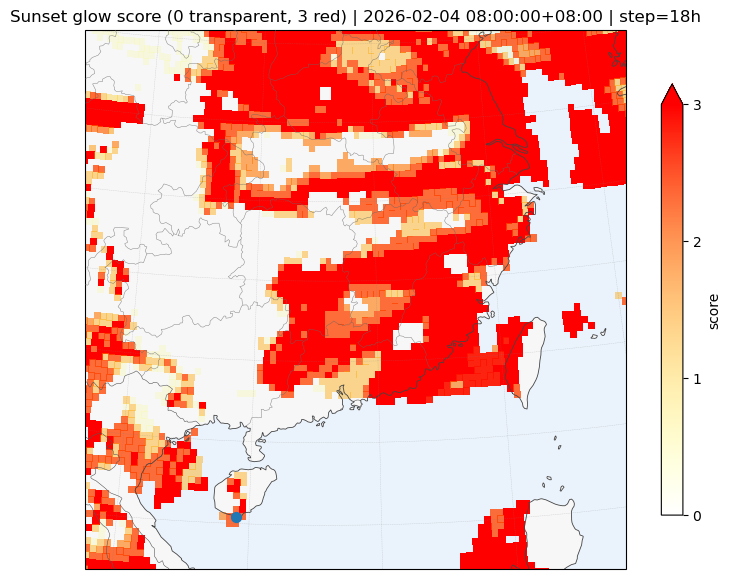

In [68]:
score_v1, aux = sunset_score_field_v1(ds)

# 如果你希望依然限制在 0..3，可以 clip 一下（看你是否想让结构/风/气压把分数推高）
score_v1 = score_v1.clip(min=0, max=5)

plot_score_map(score_v1, ds, step_idx=0)